<a href="https://colab.research.google.com/github/michalokraska/michalokraska/blob/main/Employee_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

#Wczytanie danych i zapozanie sie z nimi

In [179]:
df = pd.read_csv('/content/drive/MyDrive/data/Employee.csv')

In [180]:
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [182]:
df.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


In [183]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [184]:
df.duplicated().sum()

np.int64(1889)

In [185]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(2128)

In [186]:
df.groupby(list(df.columns[:-1]))['LeaveOrNot'].nunique().value_counts()

,count
LeaveOrNot,
1,2286
2,239


In [187]:
df = df.groupby(list(df.columns[:-1]), as_index=False)['LeaveOrNot'].mean()

In [188]:
df['LeaveOrNot'] = (df['LeaveOrNot'] > 0.5).astype(int)

In [189]:
df.duplicated().sum()

np.int64(0)

In [190]:
df.shape

(2525, 9)

##zmienna docelowa

In [191]:
target = df['LeaveOrNot']

In [192]:
target.value_counts(normalize=True)

,proportion
LeaveOrNot,
0,0.651089
1,0.348911


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

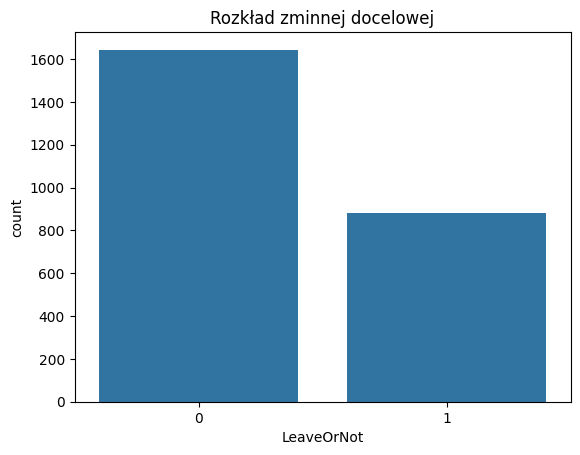

In [193]:
sns.countplot(x="LeaveOrNot", data=df)
plt.title('Rozkład zminnej docelowej')
plt

##Historgarmy zmiennych numercznych

In [194]:
num_cols = df.select_dtypes(include="number").columns

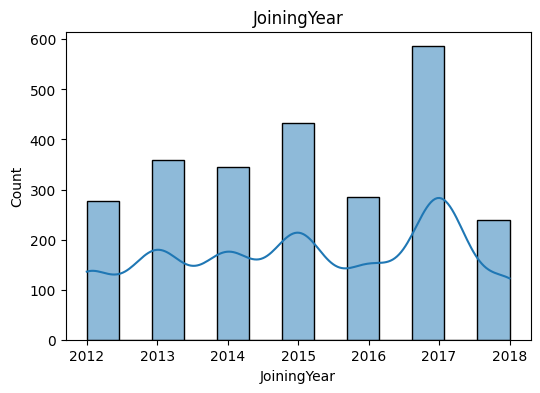

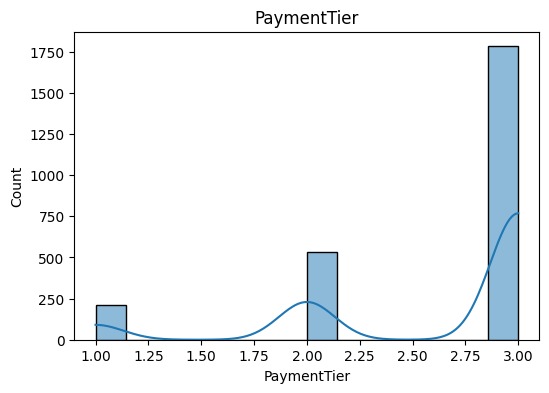

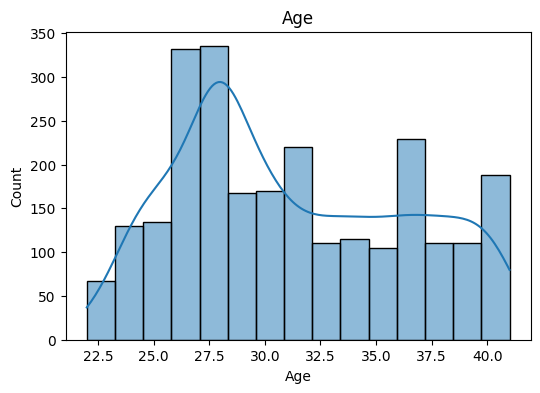

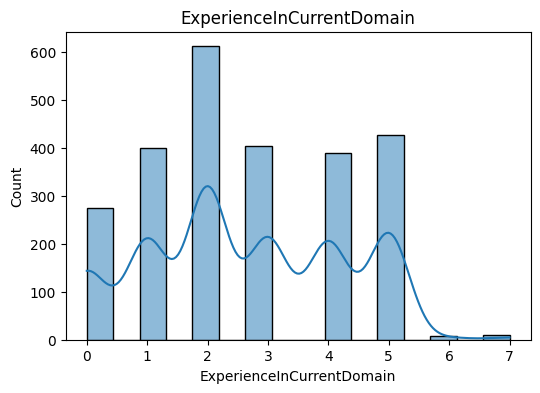

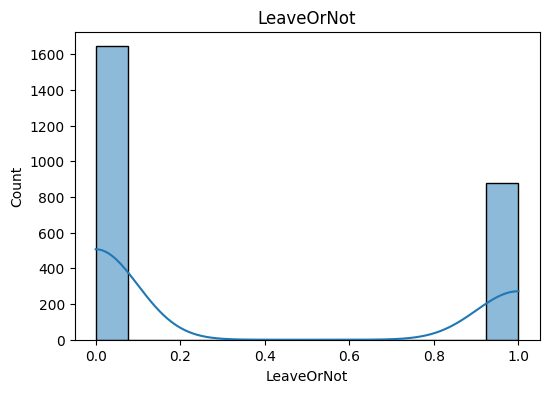

In [195]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(col)
  plt.show()

##Histogrmai zmiennych kategorycznych

In [196]:
cat_cols = df.select_dtypes(include="object").columns

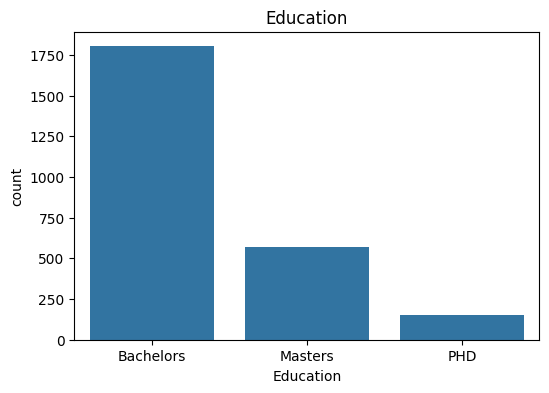

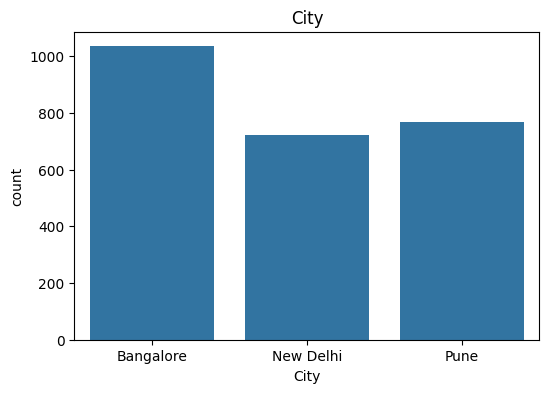

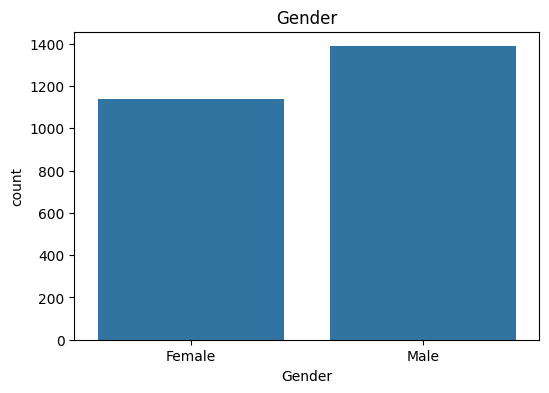

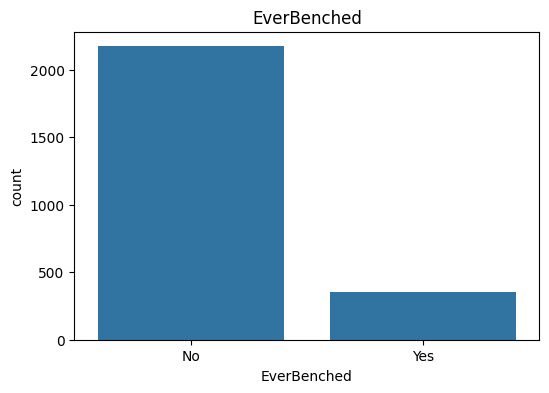

In [197]:
for col in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df, x=col)
  plt.title(col)
  plt.show()

##Odejścia w zależności od kategori

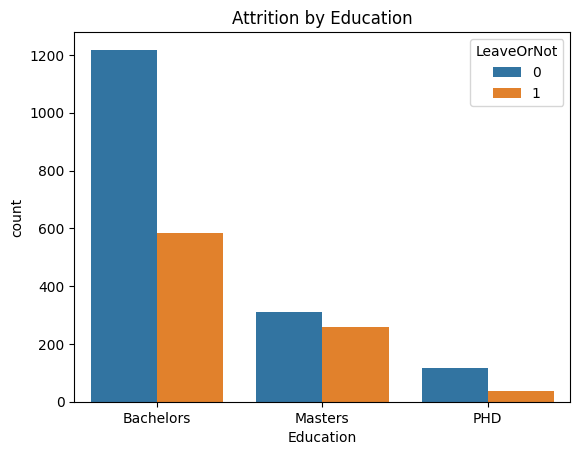

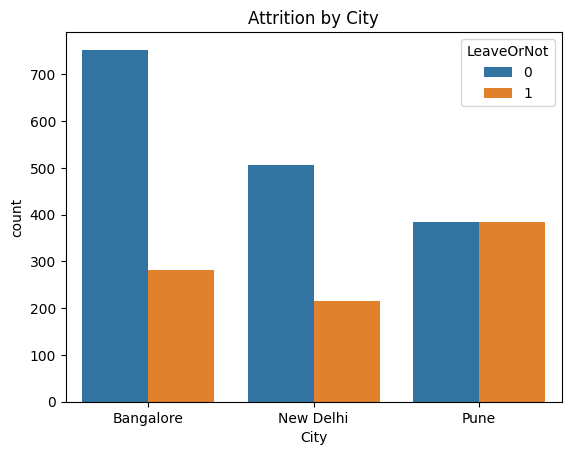

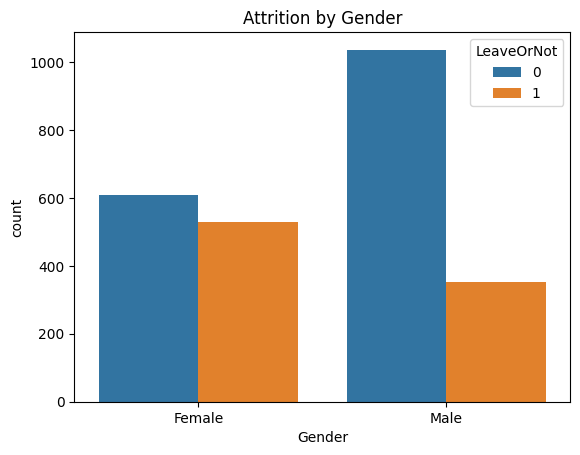

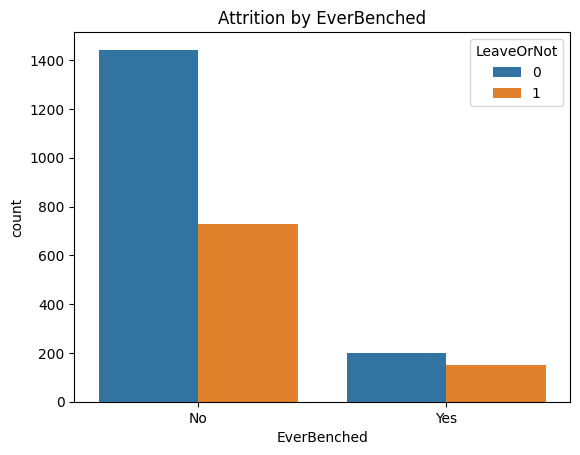

In [198]:
for col in cat_cols:
    sns.countplot(data=df, x=col, hue='LeaveOrNot')
    plt.title(f'Attrition by {col}')
    plt.show()

##Wartości odstajace

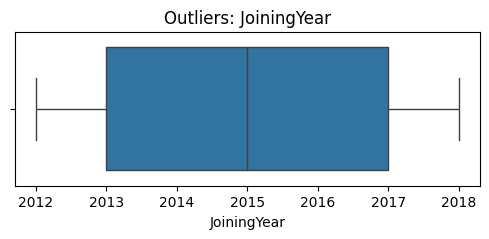

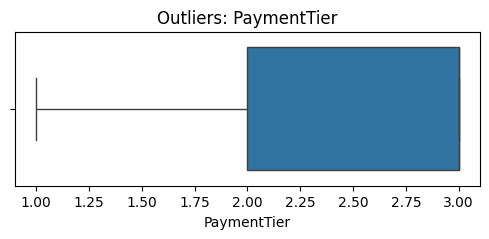

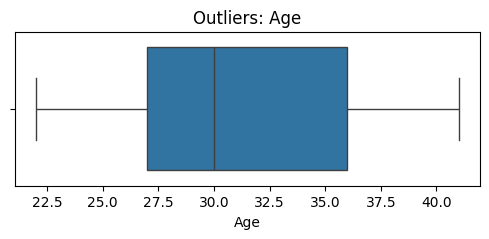

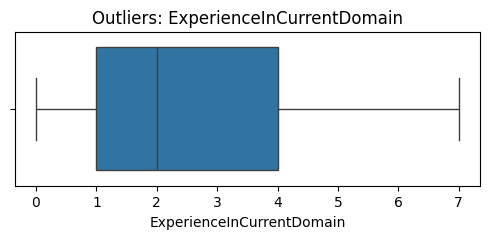

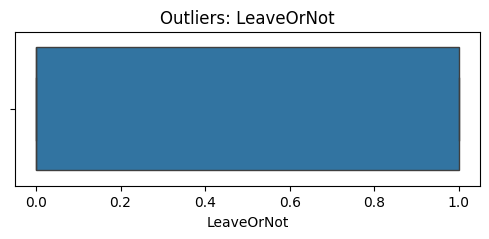

In [199]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers: {col}")
    plt.show()

##Macierz korelacji

In [200]:
corr = df[num_cols].corr()

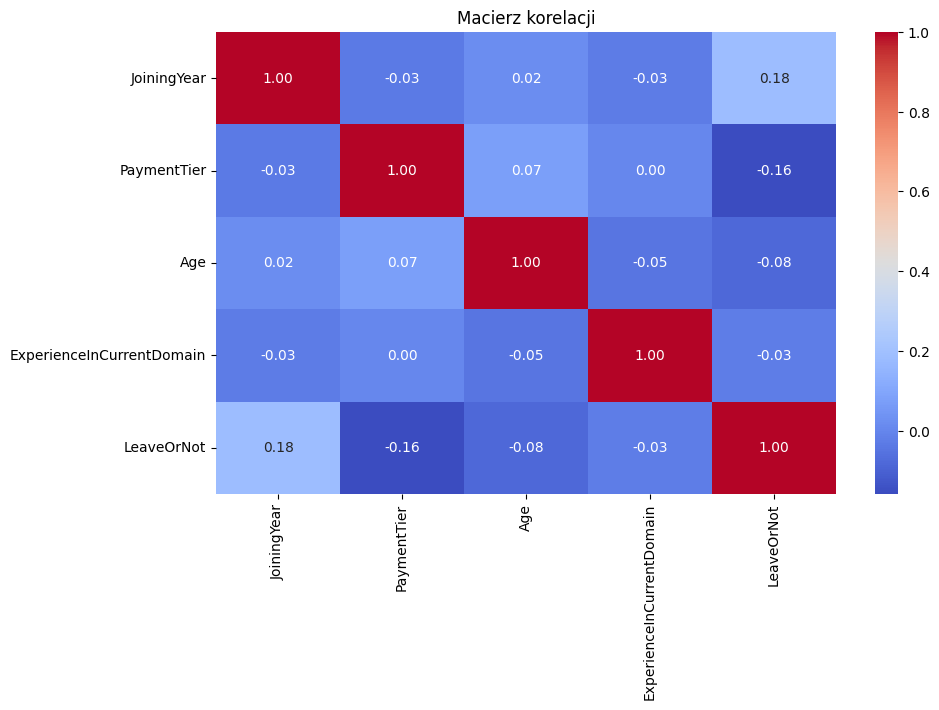

In [201]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji")
plt.show()

In [202]:
for col in cat_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])

In [203]:
corr = df.corr()

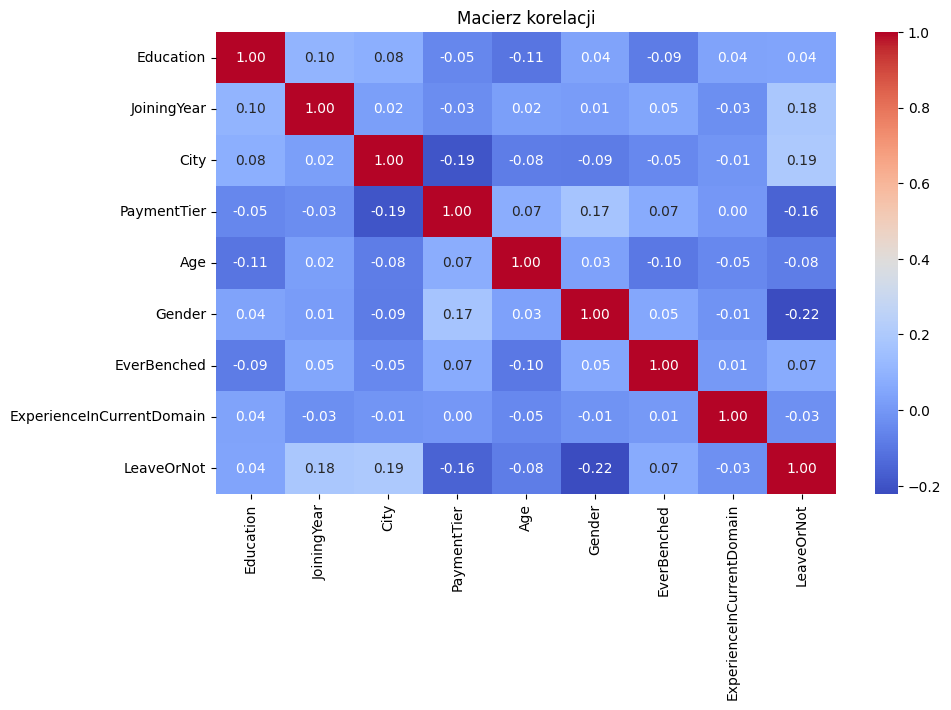

In [204]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji")
plt.show()

##Skalowanie danych

In [205]:
df_scaled = df.copy()

In [206]:
scaler = StandardScaler()

In [207]:
num_cols2 = num_cols.drop('LeaveOrNot')

In [208]:
num_cols2

Index(['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain'], dtype='object')

In [209]:
df_scaled[num_cols2] = scaler.fit_transform(df[num_cols2])

#Przygotowanie do modelowania

In [210]:
X = df_scaled
y = X.pop("LeaveOrNot")

In [211]:
print(X.shape)
print(y.shape)

(2525, 8)
(2525,)


In [212]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 41)

In [213]:
y_train.value_counts(normalize=True)

,proportion
LeaveOrNot,
0,0.651347
1,0.348653


In [214]:
target.value_counts(normalize=True)

,proportion
LeaveOrNot,
0,0.651089
1,0.348911


##tworzenie modelu


In [215]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

In [216]:
param_grids = {
    "LogisticRegression": {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs']
    },
    "DecisionTree": {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'splitter': ['best', 'random'],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    "RandomForest": {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    "GradientBoosting": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 11],
        'p': [1, 2],
        'metric': ['minkowski', 'euclidean', 'manhattan'],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'leaf_size': [10, 20, 30]
    }
}

In [217]:
best_models = {}

for name in models:
    print(f"Optymalizacja dla {name}")
    grid_search = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    print(f"Najlepsze parametry: {grid_search.best_params_}")
    print(f"Najlepszy wynik CV: {grid_search.best_score_}\n")

Optymalizacja dla LogisticRegression
Najlepsze parametry: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Najlepszy wynik CV: 0.7131409585235442

Optymalizacja dla DecisionTree
Najlepsze parametry: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'best'}
Najlepszy wynik CV: 0.8526308441875724

Optymalizacja dla RandomForest
Najlepsze parametry: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Najlepszy wynik CV: 0.8848361742820845

Optymalizacja dla GradientBoosting
Najlepsze parametry: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Najlepszy wynik CV: 0.8848361742820845

Optymalizacja dla KNN
Najlepsze parametry: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Najlepszy wynik CV: 0.8388742304309587



In [218]:
best_models

{'LogisticRegression': LogisticRegression(C=0.1, max_iter=1000, solver='liblinear'),
 'DecisionTree': DecisionTreeClassifier(criterion='entropy', max_features='log2',
                        min_samples_leaf=2),
 'RandomForest': RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=2,
                        n_estimators=50),
 'GradientBoosting': GradientBoostingClassifier(max_depth=5, min_samples_split=5, n_estimators=50),
 'KNN': KNeighborsClassifier(leaf_size=20, p=1)}

##Model Random Forest

In [219]:
model_random_forest = best_models['RandomForest']

In [220]:
y_pred = model_random_forest.predict(X_test)

In [221]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Dokładność modelu: {accuracy}")


Dokładność modelu: 0.870253164556962


In [222]:
confusion_matrix(y_test, y_pred)

array([[398,  13],
       [ 69, 152]])

##Model Gredient Boosting

In [223]:
model_GradientBoosting = best_models['GradientBoosting']

In [224]:
y_pred = model_GradientBoosting.predict(X_test)

In [225]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Dokładność modelu: {accuracy}")

Dokładność modelu: 0.870253164556962


In [226]:
confusion_matrix(y_test, y_pred)

array([[391,  20],
       [ 62, 159]])